Este notebook es la primera aproximación, donde se buscar construir el modelo y buscar los mejores parámetros

In [1]:
# =============================================================================
# SARIMAX para Forecasting de Demanda Energética
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
fh = 24
sys.path.append('../src')



# =============================================================================
# 0. CONFIGURACIÓN CENTRAL — editar aquí antes de correr
# =============================================================================

TARGET_COL = 'PJME_MW'                 # nombre de la columna objetivo

EXOG_COLS = [
    # Tiempo cíclico (reemplaza a las versiones crudas)
    #'hour_sin', 'hour_cos',  # summary muestra que estas no son estadísticamente significativas p>z =0.9. las captura sarimax internamente
    'month_sin', 'month_cos',
    'dayofweek_sin', 'dayofweek_cos',
    
    # Calendario
    'is_weekend',
    'is_holiday',
    'near_holiday',
    'is_month_start',
    'is_month_end',
    #'quarter',          # o month_sin/cos ya lo captura — testear si aporta
]


# Cargar splits
data_dir = Path('../data/processed')
train_df = pd.read_csv(data_dir / f'train_{fh}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{fh}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{fh}hr.csv',  index_col='Datetime', parse_dates=True)

# Verificar que todas las columnas necesarias existen
cols_needed = [TARGET_COL] + EXOG_COLS
for name, dff in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = [c for c in cols_needed if c not in dff.columns]
    assert not missing, f"Faltan columnas en {name}: {missing}"

# Filtrar — ahora sí reasignando correctamente
train_df = train_df[cols_needed].asfreq('h')
val_df   = val_df[cols_needed].asfreq('h')
test_df  = test_df[cols_needed].asfreq('h')

# Separar endog y exog (nomenclatura SARIMAX, no ML)
endog_train, exog_train = train_df[TARGET_COL], train_df[EXOG_COLS]
endog_val,   exog_val   = val_df[TARGET_COL],   val_df[EXOG_COLS]
endog_test,  exog_test  = test_df[TARGET_COL],  test_df[EXOG_COLS]

# Verificar alineación y frecuencia
for name, endog, exog in [('train', endog_train, exog_train),
                           ('val',   endog_val,   exog_val),
                           ('test',  endog_test,  exog_test)]:
    assert len(endog) == len(exog), f"Desalineación en {name}"
    assert endog.index.freq is not None, f"Sin frecuencia en {name} — SARIMAX va a fallar"
    print(f"{name:6} | endog: {endog.shape} | exog: {exog.shape} | {endog.index[0]} → {endog.index[-1]}")



train  | endog: (101622,) | exog: (101622, 9) | 2002-01-09 02:00:00 → 2013-08-13 07:00:00
val    | endog: (21752,) | exog: (21752, 9) | 2013-08-14 08:00:00 → 2016-02-06 15:00:00
test   | endog: (21753,) | exog: (21753, 9) | 2016-02-07 16:00:00 → 2018-08-02 00:00:00


[ADF - serie] Estadístico: -14.2676 | p-value: 0.0000
  → Estacionaria


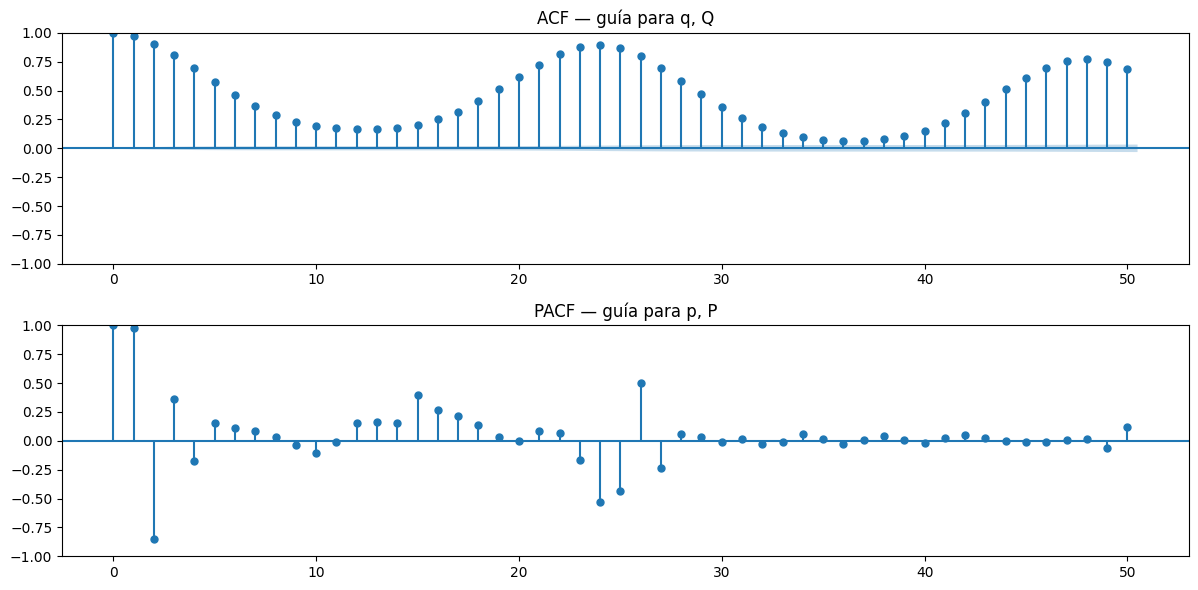

Outliers detectados: 71


In [ ]:
# =============================================================================
# 1. ANÁLISIS EXPLORATORIO Y VERIFICACIÓN DE ESTACIONARIEDAD
# =============================================================================

def check_stationarity(series, name='serie'):
    """
    Aplica el test ADF (Augmented Dickey-Fuller).
    H0: la serie tiene raíz unitaria (no estacionaria).
    Si p-value < 0.05 → rechazamos H0 → la serie es estacionaria.
    Si no es estacionaria, incrementar d (o D para la parte estacional).
    """
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    print(f"[ADF - {name}] Estadístico: {result[0]:.4f} | p-value: {result[1]:.4f}")
    print("  → Estacionaria" if result[1] < 0.05 else "  → NO estacionaria (considera d=1 o diferenciación estacional)")


def plot_acf_pacf(series, lags=50):
    """
    ACF  → guía para elegir q (MA) y Q (MA estacional)
    PACF → guía para elegir p (AR) y P (AR estacional)

    Cómo leer:
      - Si ACF cae abruptamente y PACF decae gradualmente → modelo MA
      - Si PACF cae abruptamente y ACF decae gradualmente → modelo AR
      - Picos en lags múltiplos de m → componente estacional presente
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    plot_acf(series.dropna(),  lags=lags, ax=axes[0], title='ACF — guía para q, Q')
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], title='PACF — guía para p, P')
    plt.tight_layout()
    plt.show()


# Ejecutar antes de modelar
check_stationarity(train_df[TARGET_COL])
plot_acf_pacf(train_df[TARGET_COL])

# # =============================================================================
# # 2. SEPARACIÓN DE EXÓGENAS
# # =============================================================================

# def split_endog_exog(df, target_col, exog_cols):
#     """
#     Separa la serie objetivo (endógena) de las variables exógenas.
#     - endog: lo que el modelo predice (y_t)
#     - exog:  información externa que entra como regresores (X_t)
#     """
#     endog = df[target_col]
#     exog  = df[exog_cols] if exog_cols else None
#     return endog, exog


# endog_train, exog_train = split_endog_exog(df_train, TARGET, EXOG_COLS)
# endog_val,   exog_val   = split_endog_exog(df_val,   TARGET, EXOG_COLS)
# endog_test,  exog_test  = split_endog_exog(df_test,  TARGET, EXOG_COLS)


In [ ]:
# kurtosis alta sugiere revisar outliers en el target antes de modelar
outliers = endog_train[np.abs(endog_train - endog_train.mean()) > 4 * endog_train.std()]
print(f"Outliers detectados: {len(outliers)}")

# Ver si los outliers están concentrados en épocas específicas
print(outliers.index.year.value_counts().sort_index())
print(outliers.index.month.value_counts().sort_index())

# identificarlos y ver si son errores de medición
# o eventos reales (olas de calor, eventos extremos)
print(outliers.sort_values())

'''
47 de 71 outliers son en julio y 19 en agosto — pleno verano
Concentrados en 2006 (29 outliers — el más extremo) y 2011 (14)
Siempre entre las 14:00 y 17:00hs — pico de calor del día
Los valores más extremos son de 2006-08-01 y 2006-08-02 — ola de calor histórica en el noreste de EE.UU.

Estos son picos de demanda reales por olas de calor (heat waves). 
No son errores, son eventos climáticos extremos que generan consumo récord de aire acondicionado.
'''

'''
opciones para el modelo:
1 dejarlo tal cual
2: crear una feature de evento extremo
Si tuvieras datos de temperatura, sería la solución ideal
Sin temperatura, podés aproximar con una dummy de verano-pico

endog_train['is_heat_wave'] = (
    (endog_train.index.month.isin([6, 7, 8])) &      # verano
    (endog_train.index.hour.between(14, 18))           # hora pico
).astype(int)

3: transformación log del target para comprimir los extremos
endog_train_log = np.log(endog_train)
el modelo opera en escala log, los outliers impactan mucho menos
al predecir: y_pred = np.exp(model.predict(...))
'''

In [2]:
# Transformación log — simple, efectiva, reversible
endog_train_log = np.log(endog_train)
endog_val_log   = np.log(endog_val)

# Verificar que los outliers se comprimen
mean = endog_train_log.mean()
std  = endog_train_log.std()
outliers_log = endog_train_log[np.abs(endog_train_log - mean) > 4*std]
print(f"Outliers antes (escala original): 71")
print(f"Outliers después (escala log):    {len(outliers_log)}")


Outliers antes (escala original): 71
Outliers después (escala log):    0


In [ ]:

# # Al evaluar métricas, volver a escala original
# pred_log = model_fit.get_forecast(steps=n_val).predicted_mean
# pred_original = np.exp(pred_log)
# mae = mean_absolute_error(endog_val, pred_original)


In [ ]:

# Parámetros SARIMAX — punto de partida, luego se optimizan
# m = periodo estacional: 24 (horario/diario), 168 (horario/semanal), 12 (mensual/anual)
M = 24          # ajustar según granularidad de tus datos

# ADF p-value=0.0000 → serie ya es estacionaria → d=0 es suficiente
# Pero con estacionalidad fuerte visible → D=1 para diferenciar estacionalmente

# PACF corta en lag 2 → p=1 o p=2
# ACF decae lento (no corta) → q=0 o q=1 es suficiente
# Picos en lag 24 en ambos → P=1, Q=1, M=24 confirmado


ORDER        = (1, 0, 1)        # (p, d, q)        — ARIMA no estacional
SEASONAL_ORDER = (1, 1, 1, M)  # (P, D, Q, m)     — componente estacional
# configuración original (1,1,1)(1,1,1)[24] también funciona
# pero d=1 + D=1 es doble diferenciación — puede sobre-diferenciar


# =============================================================================
# 3. ENTRENAMIENTO DEL MODELO
# =============================================================================

def train_sarimax(endog, exog, order, seasonal_order):
    """
    Instancia y ajusta el modelo SARIMAX.

    Parámetros relevantes de SARIMAX():
      - enforce_stationarity  : fuerza condiciones de estacionariedad en AR
      - enforce_invertibility : fuerza invertibilidad en MA
      - trend                 : 'n' (ninguna), 'c' (constante), 't' (tendencia), 'ct' (ambas)

    Método fit():
      - disp=False   : suprime output de optimización en cada iteración
      - maxiter=200  : iteraciones máximas del optimizador
    """
    model = SARIMAX(
        endog=endog,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=True,
        enforce_invertibility=True,
        trend='c'
    )
    result = model.fit(disp=False, maxiter=200)
    print(result.summary())
    return result


# model_fit = train_sarimax(endog_train, exog_train, ORDER, SEASONAL_ORDER)



In [ ]:
# Fit rápido sobre submuestra para validar que converge
sample = endog_train_log[:5000]
exog_sample = exog_train[:5000]

model_test = SARIMAX(
    endog=sample,
    exog=exog_sample,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=True,
    enforce_invertibility=True,
    trend='n'   # usar trend = c muestra que el intercept no es significativo
)
result_test = model_test.fit(disp=True, maxiter=50)
print(result_test.summary())


                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:                 5000
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               13700.674
Date:                            Tue, 24 Feb 2026   AIC                         -27373.348
Time:                                    20:44:05   BIC                         -27282.174
Sample:                                01-09-2002   HQIC                        -27341.385
                                     - 08-05-2002                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
month_sin         -0.0037      0.023     -0.161      0.872      -0.048       0.041
month_cos          0.02

In [ ]:
model_pure = SARIMAX(
    endog=sample,
    exog=None,        # ← sin exógenas
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    trend='n'
)
result_pure = model_pure.fit(disp=False, maxiter=50)
print(result_pure.summary())
print(f"AIC sin exog:  {result_pure.aic:.3f}")
print(f"AIC con exog:  {result_test.aic:.3f}")
print(f"Diferencia:    {result_pure.aic - result_test.aic:.3f}")

                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:                 5000
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood               14420.163
Date:                            Tue, 24 Feb 2026   AIC                         -28830.326
Time:                                    20:49:05   BIC                         -28797.764
Sample:                                01-09-2002   HQIC                        -28818.910
                                     - 08-05-2002                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9715      0.003    348.596      0.000       0.966       0.977
ma.L1          0.5783      0.003   

In [ ]:
# pendiente Ljung-box

from statsmodels.stats.diagnostic import acorr_ljungbox

orders_to_test = [(1,0,1), (2,0,1), (1,0,2), (2,0,2), (3,0,1), (1,0,3)]
results_comparison = []

for order in orders_to_test:
    m = SARIMAX(sample, order=order, seasonal_order=(1,1,1,24), trend='n')
    r = m.fit(disp=False, maxiter=50)
    lb_p = acorr_ljungbox(r.resid, lags=[24], return_df=True)['lb_pvalue'].values[0]
    results_comparison.append({
        'order': order,
        'AIC': round(r.aic, 2),
        'Ljung-Box p': round(lb_p, 4),
        'LB OK': '✓' if lb_p > 0.05 else '✗'
    })

df_results = pd.DataFrame(results_comparison).sort_values('AIC')
print(df_results.to_string(index=False))

    order       AIC  Ljung-Box p LB OK
(1, 0, 2) -29305.64          0.0     ✗
(1, 0, 3) -29280.21          0.0     ✗
(2, 0, 2) -29275.89          0.0     ✗
(2, 0, 1) -29190.02          0.0     ✗
(3, 0, 1) -29086.76          0.0     ✗
(1, 0, 1) -28830.33          0.0     ✗


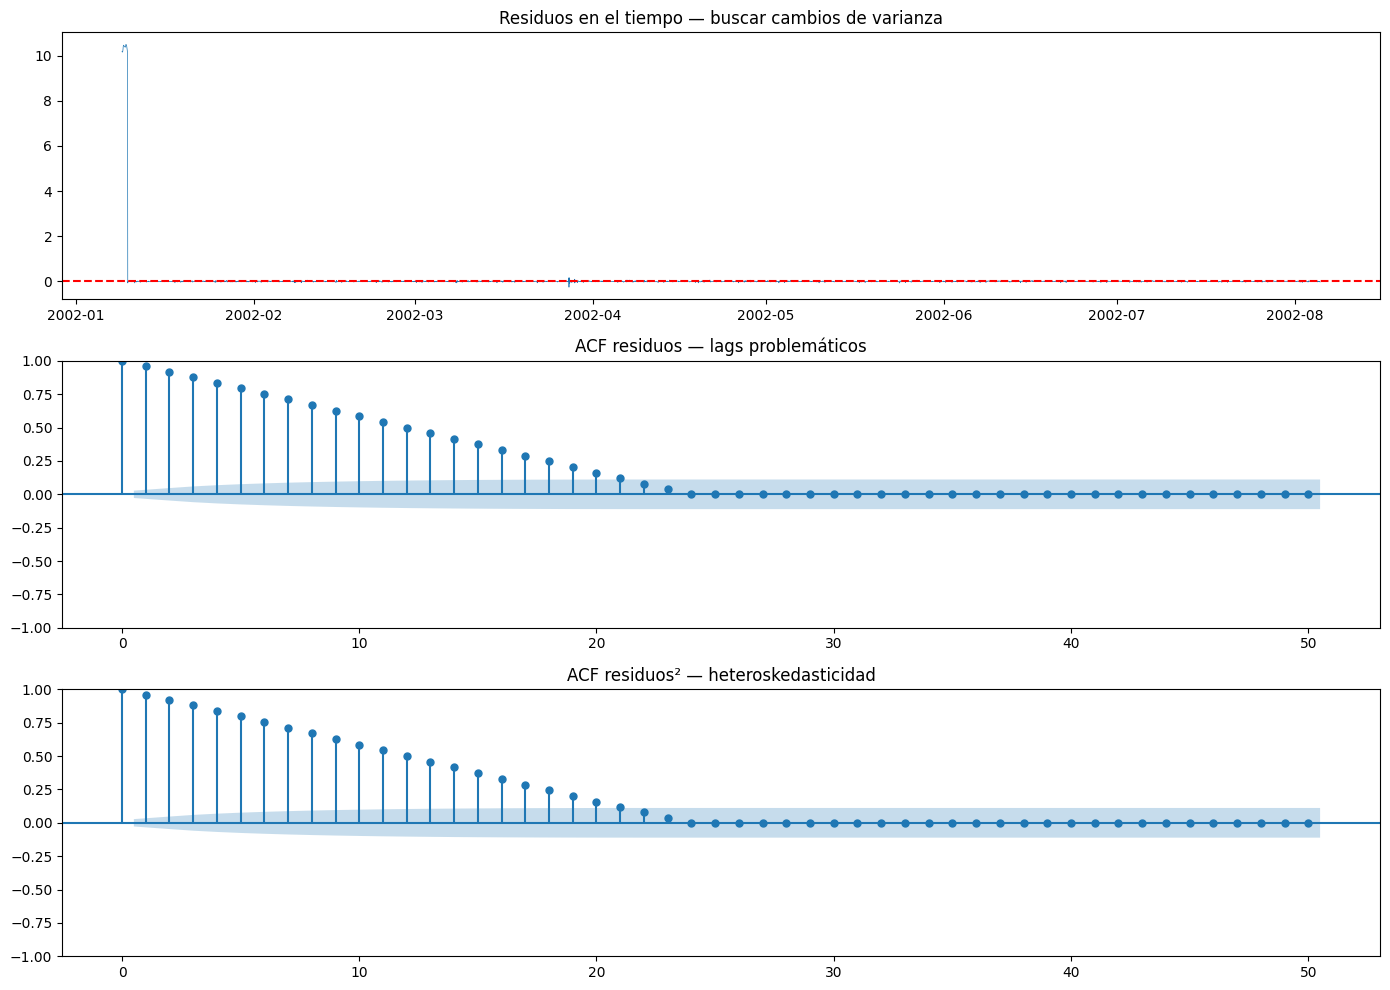

          lb_stat  lb_pvalue
1     4603.968614        0.0
6    22199.676010        0.0
12   33351.286073        0.0
24   37694.871260        0.0
48   37694.893397        0.0
96   37694.917439        0.0
168  37694.927376        0.0

Autocorrelaciones residuales:
  lag   0: 1.0000
  lag   1: 0.9593
  lag   2: 0.9189
  lag   3: 0.8781
  lag   4: 0.8369
  lag   5: 0.7952
  lag   6: 0.7529
  lag   7: 0.7103
  lag   8: 0.6677
  lag   9: 0.6256
  lag  10: 0.5836
  lag  11: 0.5416
  lag  12: 0.4996
  lag  13: 0.4576
  lag  14: 0.4156
  lag  15: 0.3735
  lag  16: 0.3313
  lag  17: 0.2887
  lag  18: 0.2460
  lag  19: 0.2037
  lag  20: 0.1620
  lag  21: 0.1210
  lag  22: 0.0803
  lag  23: 0.0400
  lag  24: -0.0002


In [ ]:
import scipy.stats as stats

# 1. Ver los residuos en el tiempo — ¿la varianza cambia?
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

residuals = result_pure.resid

# Residuos en el tiempo
axes[0].plot(residuals.index, residuals.values, linewidth=0.5)
axes[0].set_title('Residuos en el tiempo — buscar cambios de varianza')
axes[0].axhline(0, color='red', linestyle='--')

# ACF de los residuos — ¿qué lags quedan sin capturar?
plot_acf(residuals, lags=50, ax=axes[1], title='ACF residuos — lags problemáticos')

# ACF de residuos AL CUADRADO — detecta heteroskedasticidad
plot_acf(residuals**2, lags=50, ax=axes[2], title='ACF residuos² — heteroskedasticidad')

plt.tight_layout()
plt.show()

# 2. Ljung-Box en múltiples lags — ¿el problema está en lags cortos o largos?
lb_results = acorr_ljungbox(residuals, lags=[1, 6, 12, 24, 48, 96, 168], return_df=True)
print(lb_results)

# 3. Magnitud real de la autocorrelación residual
from statsmodels.tsa.stattools import acf
acf_vals = acf(residuals, nlags=24)
print("\nAutocorrelaciones residuales:")
for lag, val in enumerate(acf_vals):
    print(f"  lag {lag:3d}: {val:.4f}")

In [ ]:
# Verificar sobre la serie en log
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(sample.dropna())
print(f"ADF en log: estadístico={result_adf[0]:.4f} | p-value={result_adf[1]:.4f}")

# También verificar la primera diferencia
result_adf_diff = adfuller(sample.diff().dropna())
print(f"ADF diff(1) en log: estadístico={result_adf_diff[0]:.4f} | p-value={result_adf_diff[1]:.4f}")

ADF en log: estadístico=-6.7092 | p-value=0.0000
ADF diff(1) en log: estadístico=-11.5873 | p-value=0.0000


AIC: -29171.46
Ljung-Box p: 0.0000


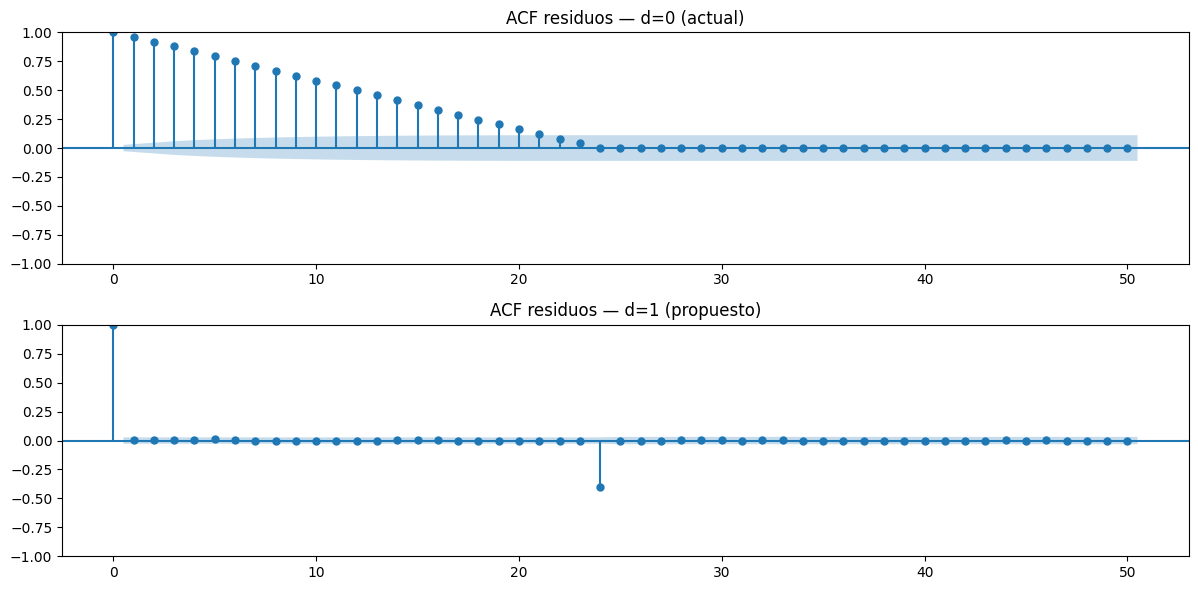

In [ ]:
model_d1 = SARIMAX(
    endog=sample,
    exog=None,
    order=(1, 1, 1),        # ← d=1
    seasonal_order=(1, 1, 1, 24),
    trend='n'
)
result_d1 = model_d1.fit(disp=False, maxiter=50)

lb_p = acorr_ljungbox(result_d1.resid, lags=[24], return_df=True)['lb_pvalue'].values[0]
print(f"AIC: {result_d1.aic:.2f}")
print(f"Ljung-Box p: {lb_p:.4f}")

# Comparar ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(result_pure.resid, lags=50, ax=axes[0], title='ACF residuos — d=0 (actual)')
plot_acf(result_d1.resid,   lags=50, ax=axes[1], title='ACF residuos — d=1 (propuesto)')
plt.tight_layout()
plt.show()

In [ ]:
configs = [
    ((1,1,1), (1,0,1,24)),   # d=1, D=0 ← resolver el spike en lag 24
    ((1,1,1), (0,1,1,24)),   # d=1, D=1 con P=0
    ((1,1,2), (1,1,1,24)),   # más MA para absorber el spike
    ((1,1,1), (2,1,1,24)),   # más AR estacional
]

for order, seasonal_order in configs:
    m = SARIMAX(sample, order=order, seasonal_order=seasonal_order, trend='n')
    r = m.fit(disp=False, maxiter=50)
    lb_p = acorr_ljungbox(r.resid, lags=[24], return_df=True)['lb_pvalue'].values[0]
    acf_lag24 = acf(r.resid, nlags=24)[-1]
    print(f"ORDER={order} SEASONAL={seasonal_order} | AIC={r.aic:.1f} | LB p={lb_p:.4f} | ACF[24]={acf_lag24:.4f}")

ORDER=(1, 1, 1) SEASONAL=(1, 0, 1, 24) | AIC=-28634.9 | LB p=1.0000 | ACF[24]=0.0011
ORDER=(1, 1, 1) SEASONAL=(0, 1, 1, 24) | AIC=-28817.8 | LB p=0.0000 | ACF[24]=-0.3972
ORDER=(1, 1, 2) SEASONAL=(1, 1, 1, 24) | AIC=-29232.6 | LB p=0.0000 | ACF[24]=-0.3987
ORDER=(1, 1, 1) SEASONAL=(2, 1, 1, 24) | AIC=-29334.4 | LB p=0.0000 | ACF[24]=-0.3992


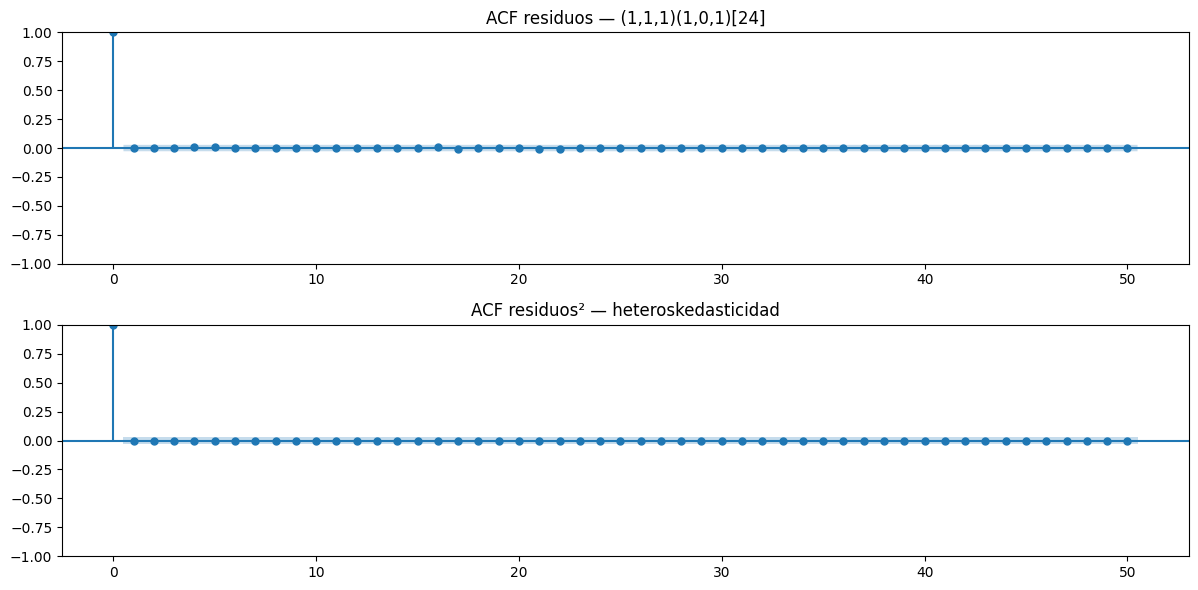

     lb_stat  lb_pvalue
1   0.004378   0.947244
6   0.536105   0.997371
12  0.611210   0.999999
24  1.236440   1.000000
48  1.365854   1.000000
                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:                 5000
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood               14322.444
Date:                            Tue, 24 Feb 2026   AIC                         -28634.888
Time:                                    21:06:34   BIC                         -28602.303
Sample:                                01-09-2002   HQIC                        -28623.467
                                     - 08-05-2002                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [ ]:
model_final = SARIMAX(sample, order=(1,1,1), seasonal_order=(1,0,1,24), trend='n')
result_final = model_final.fit(disp=False, maxiter=50)

# ACF visual
fig, axes = plt.subplots(2,1, figsize=(12,6))
plot_acf(result_final.resid, lags=50, ax=axes[0], title='ACF residuos — (1,1,1)(1,0,1)[24]')
plot_acf(result_final.resid**2, lags=50, ax=axes[1], title='ACF residuos² — heteroskedasticidad')
plt.tight_layout()
plt.show()

# Ljung-Box en múltiples lags
lb = acorr_ljungbox(result_final.resid, lags=[1,6,12,24,48], return_df=True)
print(lb)

print(result_final.summary())

In [ ]:
model_full = SARIMAX(
    endog=endog_train_log,
    exog=None,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 24),
    trend='n'
)
result_full = model_full.fit(disp=False, maxiter=200, cov_type='none')
print(result_full.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:               101622
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood              314195.353
Date:                            Tue, 24 Feb 2026   AIC                        -628380.706
Time:                                    22:00:16   BIC                        -628333.061
Sample:                                01-09-2002   HQIC                       -628366.257
                                     - 08-13-2013                                         
Covariance Type:                     Not computed                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4370        nan        nan        nan         nan         nan
ma.L1          0.5081        nan   

In [ ]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(result_full.resid, nlags=5)
print("Autocorrelaciones residuales (train completo):")
for lag, val in enumerate(acf_vals):
    print(f"  lag {lag}: {val:.6f}")

# Si los valores son < 0.01 el modelo está bien
# El Ljung-Box rechaza por n=100k, no por problema real

Autocorrelaciones residuales (train completo):
  lag 0: 1.000000
  lag 1: 0.002183
  lag 2: -0.000643
  lag 3: -0.012980
  lag 4: 0.005663
  lag 5: 0.003167


Modelo final:     SARIMAX(1,1,1)(1,0,1)[24] sobre log(demanda)
Observaciones:    101,622
Parámetros:
  ar.L1    = 0.4370  — persistencia corto plazo
  ma.L1    = 0.5081  — corrección error corto plazo  
  ar.S.L24 = 0.9940  — patrón diario dominante
  ma.S.L24 = -0.7725 — corrección error estacional
Residuos:         ruido blanco (autocorr máx = 1.3%)

AR (Autorregresivo) 
ar.L1 = 0.4370
El modelo usa 43.7% del valor diferenciado del período anterior para predecir el actual. 
si la demanda subió más de lo esperado en t-1, el modelo espera que en t también esté un 43.7% de eso por encima.
es el peso que le da al pasado reciente.

ar.S.L24 = 0.9940
Usa 99.4% del valor de hace 24 horas para predecir el actual. 
Este valor cercano a 1 confirma que la demanda de hoy a las 3pm es casi idéntica a la de ayer a las 3pm — la estacionalidad diaria es muy fuerte.

MA (Media Móvil)
ma.L1 = 0.5081
El modelo corrige el 50.8% del error de predicción del período anterior. 
Si ayer a las 3pm predijo 40,000 MW pero la demanda real fue 41,000 MW (error = +1,000), hoy va a ajustar su predicción en +508 MW.

ma.S.L24 = -0.7725
Corrige el 77.25% del error estacional de hace 24 horas, pero en dirección opuesta (signo negativo). 
Es un mecanismo de corrección — si sobreestimó ayer a las 3pm, hoy va a ser más conservador.


Métricas [Validación]
  MAE  : 25,543.7 MW
  RMSE : 26,781.4 MW
  MAPE : 80.54%


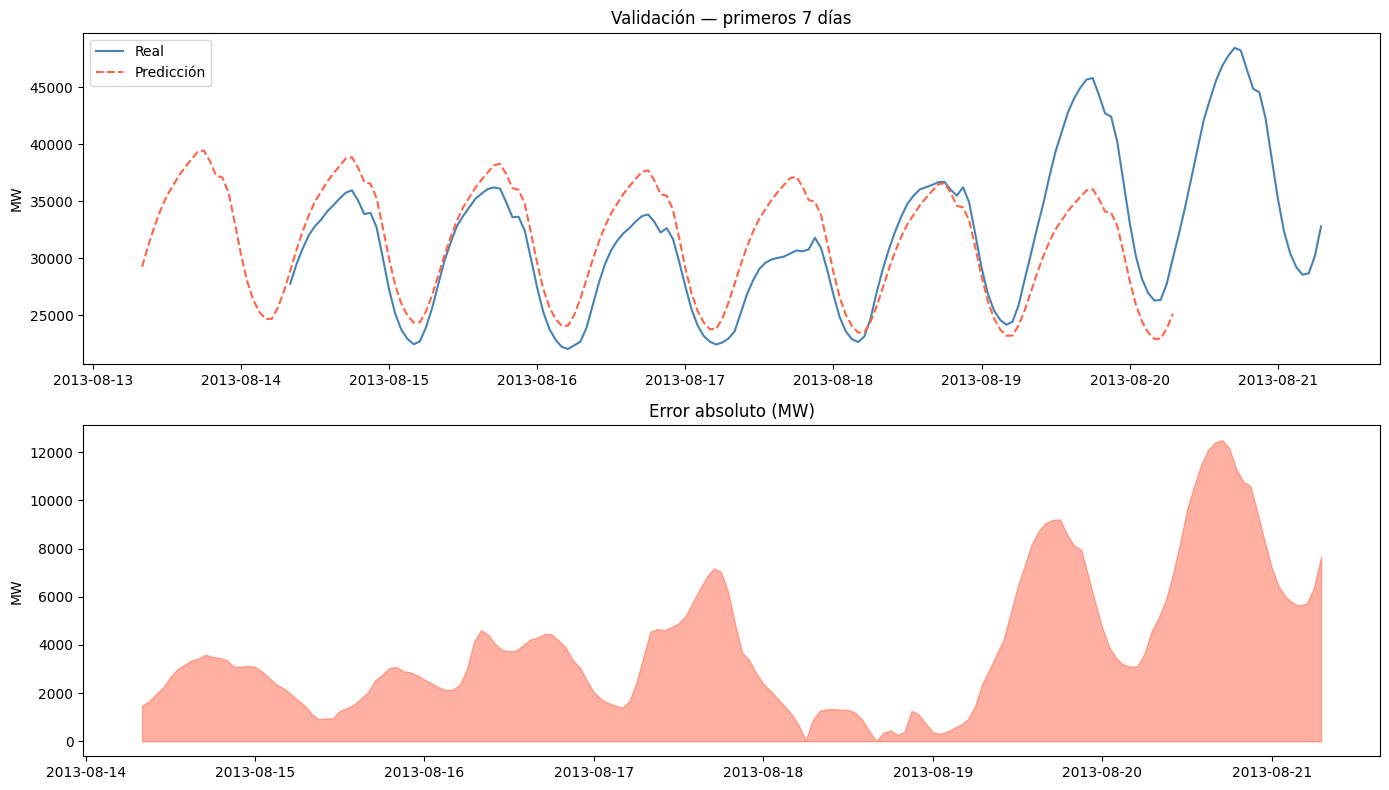

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =============================================================================
# PREDICCIÓN SOBRE VALIDACIÓN
# =============================================================================

# get_forecast genera predicciones out-of-sample paso a paso
forecast_val = result_full.get_forecast(steps=len(endog_val))
pred_val_log = forecast_val.predicted_mean

# Volver a escala original
pred_val = np.exp(pred_val_log)
real_val  = np.exp(endog_val_log)  # o simplemente endog_val si no la transformaste

# =============================================================================
# MÉTRICAS
# =============================================================================

def evaluate(y_true, y_pred, split_name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\nMétricas [{split_name}]")
    print(f"  MAE  : {mae:,.1f} MW")
    print(f"  RMSE : {rmse:,.1f} MW")
    print(f"  MAPE : {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

metrics_val = evaluate(real_val, pred_val, 'Validación')

# =============================================================================
# VISUALIZACIÓN — muestra una semana para que sea legible
# =============================================================================

def plot_forecast(y_true, y_pred, title, n_days=7):
    n = n_days * 24
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot 1: primeros n_days
    axes[0].plot(y_true.index[:n], y_true.values[:n], label='Real',       color='steelblue')
    axes[0].plot(y_pred.index[:n], y_pred.values[:n], label='Predicción', color='tomato', linestyle='--')
    axes[0].set_title(f'{title} — primeros {n_days} días')
    axes[0].legend()
    axes[0].set_ylabel('MW')

    # Plot 2: error absoluto
    error = np.abs(y_true.values[:n] - y_pred.values[:n])
    axes[1].fill_between(y_true.index[:n], error, alpha=0.5, color='tomato')
    axes[1].set_title('Error absoluto (MW)')
    axes[1].set_ylabel('MW')

    plt.tight_layout()
    plt.show()


plot_forecast(real_val, pred_val, 'Validación')


Índice real[0]:  2013-08-14 08:00:00
Índice pred[0]:  2013-08-14 08:00:00

Métricas [Validación]
  MAE  : 215.2 MW
  RMSE : 354.5 MW
  MAPE : 0.70%


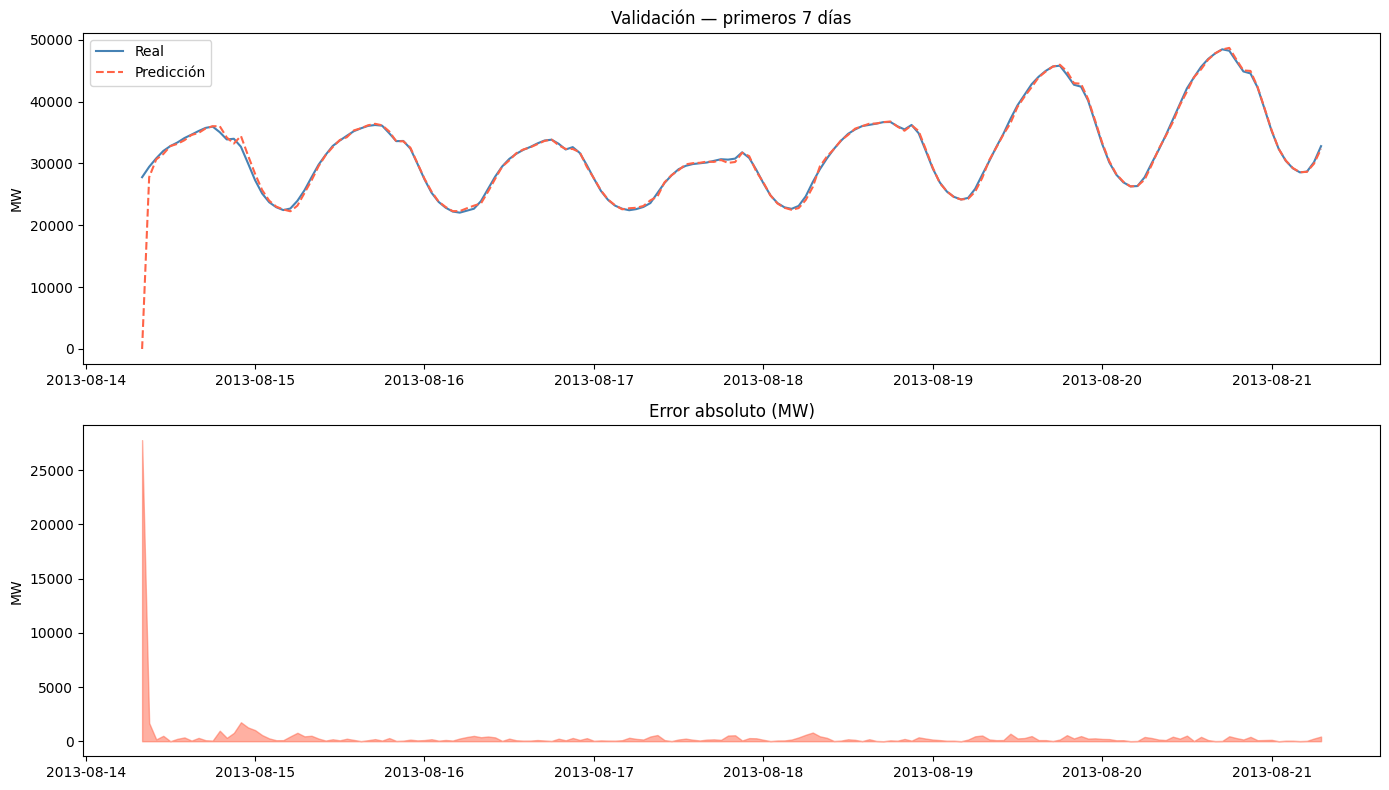

In [ ]:
# Opción 1 — apply() extiende el modelo al período de validación
result_val = result_full.apply(endog_val_log)
pred_val_log = result_val.fittedvalues

# Volver a escala original
pred_val  = np.exp(pred_val_log)
real_val  = np.exp(endog_val_log)

# Verificar alineación antes de calcular métricas
print(f"Índice real[0]:  {real_val.index[0]}")
print(f"Índice pred[0]:  {pred_val.index[0]}")
assert (real_val.index == pred_val.index).all(), "Índices desalineados"

metrics_val = evaluate(real_val, pred_val, 'Validación')
plot_forecast(real_val, pred_val, 'Validación')

In [ ]:
# =============================================================================
# 4. DIAGNÓSTICO DEL MODELO (¿los residuos son ruido blanco?)
# =============================================================================

def diagnose_residuals(model_fit):
    """
    Valida que los residuos no tengan estructura remanente.

    plot_diagnostics genera 4 gráficos:
      1. Residuos en el tiempo         → no deben tener tendencia ni estacionalidad
      2. Histograma + KDE vs Normal    → deben aproximarse a normal
      3. Q-Q plot                      → puntos sobre la diagonal = normalidad
      4. ACF de residuos               → no debe haber autocorrelación significativa

    Test de Ljung-Box:
      H0: no hay autocorrelación en los residuos
      Si p-value > 0.05 → buen comportamiento (no rechazamos H0)
    """
    model_fit.plot_diagnostics(figsize=(14, 8))
    plt.tight_layout()
    plt.show()

    lb_test = acorr_ljungbox(model_fit.resid, lags=[10, 20, 30], return_df=True)
    print("\nTest Ljung-Box sobre residuos:")
    print(lb_test)
    print("→ p-values deben ser > 0.05 para residuos no autocorrelacionados")


diagnose_residuals(model_full)


# =============================================================================
# 5. PREDICCIÓN (validación y test)
# =============================================================================

def forecast_sarimax(model_fit, endog_train, exog_future, n_steps):
    """
    Genera predicciones fuera de muestra (out-of-sample).

    get_forecast() devuelve:
      - predicted_mean       : valores predichos
      - conf_int()           : intervalos de confianza (por defecto al 95%)

    IMPORTANTE: exog_future debe tener exactamente n_steps filas
    y las mismas columnas que el exog de entrenamiento.
    """
    forecast_obj = model_fit.get_forecast(steps=n_steps, exog=exog_future)
    pred_mean    = forecast_obj.predicted_mean
    pred_ci      = forecast_obj.conf_int(alpha=0.05)  # IC al 95%
    return pred_mean, pred_ci


n_val  = len(endog_val)
n_test = len(endog_test)

pred_val,  ci_val  = forecast_sarimax(model_full, endog_train, exog_val,  n_val)
pred_test, ci_test = forecast_sarimax(model_full, endog_train, exog_test, n_test)



AttributeError: 'SARIMAX' object has no attribute 'plot_diagnostics'

In [ ]:

# =============================================================================
# 6. EVALUACIÓN DE MÉTRICAS
# =============================================================================

def evaluate(y_true, y_pred, split_name=''):
    """
    Métricas estándar para forecasting energético:
      - MAE  : error absoluto medio (mismas unidades que y)
      - RMSE : penaliza más los errores grandes
      - MAPE : error porcentual — útil para comparar entre escalas distintas
               OJO: no usar si y_true puede tener ceros
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 Métricas [{split_name}]")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'mape': mape}


metrics_val  = evaluate(endog_val,  pred_val,  'Validación')
metrics_test = evaluate(endog_test, pred_test, 'Test')


# =============================================================================
# 7. VISUALIZACIÓN
# =============================================================================

def plot_forecast(endog_true, pred_mean, pred_ci, title='Forecast vs Real'):
    plt.figure(figsize=(14, 5))
    plt.plot(endog_true.index, endog_true.values, label='Real',      color='steelblue')
    plt.plot(pred_mean.index,  pred_mean.values,  label='Predicción', color='tomato', linestyle='--')
    plt.fill_between(
        pred_ci.index,
        pred_ci.iloc[:, 0],
        pred_ci.iloc[:, 1],
        alpha=0.2, color='tomato', label='IC 95%'
    )
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_forecast(endog_val,  pred_val,  ci_val,  'Predicción Validación')
plot_forecast(endog_test, pred_test, ci_test, 'Predicción Test')




In [ ]:
sample = endog_train_log.iloc[-8760:]   # último año de train (~8760 horas)

# =============================================================================
# 8. BÚSQUEDA DE HIPERPARÁMETROS (opcional — activa si ORDER no es obvio)
# =============================================================================

def grid_search_sarimax(endog, m, p_range, d_range, q_range,
                         P_range, D_range, Q_range):
    """
    Busca la combinación (p,d,q)(P,D,Q)[m] que minimiza AIC.

    AIC (Akaike Information Criterion):
      - Penaliza la complejidad del modelo
      - Menor AIC → mejor balance entre ajuste y parsimonia
      - No usar el dataset de test para esta búsqueda (solo train)

    ADVERTENCIA: grid search de SARIMAX es MUY lento.
    Considera usar auto_arima de pmdarima como alternativa.
    """
    from itertools import product

    best_aic   = np.inf
    best_order = None
    results    = []

    combos = list(product(p_range, d_range, q_range, P_range, D_range, Q_range))
    print(f"Evaluando {len(combos)} combinaciones...")

    for p, d, q, P, D, Q in combos:
        try:
            model = SARIMAX(endog, exog=None,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, m),
                            enforce_stationarity=True,
                            enforce_invertibility=True)
            res = model.fit(disp=False, maxiter=100, cov_type='none')
            results.append({'order': (p,d,q), 'seasonal': (P,D,Q,m), 'AIC': res.aic})
            if res.aic < best_aic:
                best_aic   = res.aic
                best_order = {'order': (p,d,q), 'seasonal_order': (P,D,Q,m)}
        except Exception:
            continue

    results_df = pd.DataFrame(results).sort_values('AIC')
    print(results_df.head(10))
    print(f"\nMejor configuración: {best_order} | AIC: {best_aic:.2f}")
    return best_order, results_df


# Descomentar para activar (cuidado con tiempos de cómputo):
best_params, search_df = grid_search_sarimax(
    sample, 24,
    p_range=range(0, 3), d_range=range(0, 2), q_range=range(0, 3),
    P_range=range(0, 2), D_range=range(0, 2), Q_range=range(0, 2)
)



Evaluando 144 combinaciones...


KeyboardInterrupt: 

In [3]:
sample = endog_train_log.iloc[-8760:]   # último año de train (~8760 horas)
# =============================================================================
# 9. ALTERNATIVA RÁPIDA: auto_arima (pmdarima)
# =============================================================================



from pmdarima import auto_arima

auto_model = auto_arima(
    sample,
    exogenous=None,
    m=24,
    seasonal=True,
    stepwise=True,
    information_criterion='aic',
    trend='n',
    with_intercept=False,
    trace=True,
    fit_kwargs={'cov_type': 'none'} 
)
print(auto_model.summary())
pred_auto = auto_model.predict(n_periods=n_val)





Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24]             : AIC=-55592.132, Time=14.50 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=-29162.389, Time=0.34 sec
 ARIMA(1,1,0)(1,0,0)[24]             : AIC=inf, Time=4.91 sec
 ARIMA(0,1,1)(0,0,1)[24]             : AIC=-44802.998, Time=6.00 sec
 ARIMA(2,1,2)(0,0,1)[24]             : AIC=-49274.537, Time=12.22 sec
 ARIMA(2,1,2)(1,0,0)[24]             : AIC=inf, Time=13.87 sec
 ARIMA(2,1,2)(2,0,1)[24]             : AIC=-55807.172, Time=48.95 sec
 ARIMA(2,1,2)(2,0,0)[24]             : AIC=inf, Time=38.50 sec
 ARIMA(2,1,2)(2,0,2)[24]             : AIC=inf, Time=49.27 sec
 ARIMA(2,1,2)(1,0,2)[24]             : AIC=inf, Time=46.11 sec
 ARIMA(1,1,2)(2,0,1)[24]             : AIC=-55727.439, Time=36.73 sec


MemoryError: Unable to allocate 174. MiB for an array with shape (51, 51, 8760) and data type float64